
# SleepWise - Phase 2 Model Implementation

This notebook implements:
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

Includes:
- Proper preprocessing
- Stratified train-test split
- Evaluation metrics (Accuracy, Precision, Recall, F1-score)
- Confusion Matrix


In [4]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import seaborn as sns
import matplotlib.pyplot as plt



## Load Dataset



In [5]:

df = pd.read_csv('Sleep_Efficiency.csv')
df.head()


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


## Preprocessing

In [6]:

# Handle missing values
df = df.dropna()

# Create sleep quality categories using quantiles (IMPORTANT FIX)
df['sleep_quality'] = pd.qcut(df['Sleep efficiency'], q=3, labels=['Poor', 'Moderate', 'Good'])

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency,sleep_quality
0,1,65,0,57,57,6.0,0.88,18,70,12,0.0,0.0,0.0,1,3.0,Moderate
1,2,69,1,340,348,7.0,0.66,19,28,53,3.0,0.0,3.0,1,3.0,Poor
2,3,40,0,129,131,8.0,0.89,20,70,10,1.0,0.0,0.0,0,3.0,Good
3,4,40,0,300,308,6.0,0.51,23,25,52,3.0,50.0,5.0,1,1.0,Poor
4,5,57,1,66,66,8.0,0.76,27,55,18,3.0,0.0,3.0,0,3.0,Moderate


In [7]:

X = df.drop(['sleep_quality', 'Sleep efficiency'], axis=1)
y = df['sleep_quality']


## Train-Test Split (Stratified)

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## Feature Scaling

In [9]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Model Training & Evaluation


Model: Logistic Regression
Accuracy : 0.7436
Precision: 0.7600
Recall   : 0.7436
F1-Score : 0.7413

Classification Report:

              precision    recall  f1-score   support

        Good       0.68      0.92      0.78        25
    Moderate       0.65      0.56      0.60        27
        Poor       0.95      0.77      0.85        26

    accuracy                           0.74        78
   macro avg       0.76      0.75      0.74        78
weighted avg       0.76      0.74      0.74        78



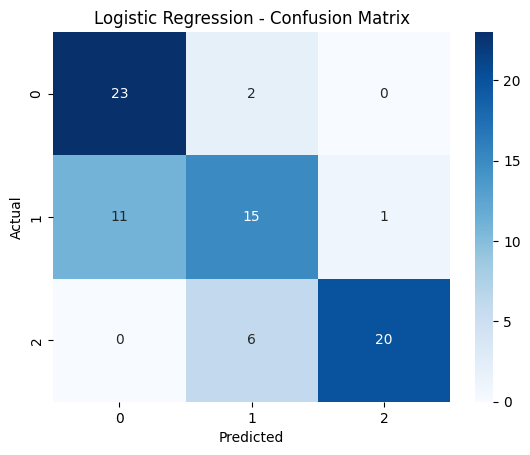


Model: Decision Tree
Accuracy : 0.5897
Precision: 0.5806
Recall   : 0.5897
F1-Score : 0.5799

Classification Report:

              precision    recall  f1-score   support

        Good       0.50      0.36      0.42        25
    Moderate       0.48      0.56      0.52        27
        Poor       0.76      0.85      0.80        26

    accuracy                           0.59        78
   macro avg       0.58      0.59      0.58        78
weighted avg       0.58      0.59      0.58        78



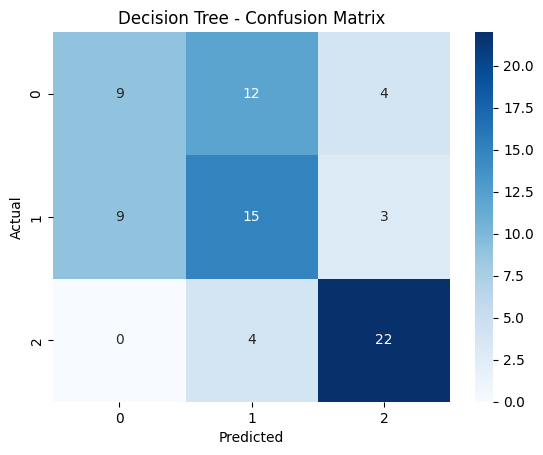


Model: Random Forest
Accuracy : 0.7051
Precision: 0.7341
Recall   : 0.7051
F1-Score : 0.7127

Classification Report:

              precision    recall  f1-score   support

        Good       0.63      0.76      0.69        25
    Moderate       0.57      0.59      0.58        27
        Poor       1.00      0.77      0.87        26

    accuracy                           0.71        78
   macro avg       0.73      0.71      0.71        78
weighted avg       0.73      0.71      0.71        78



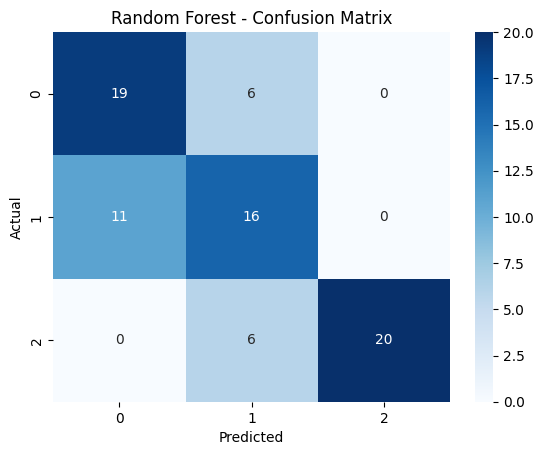


Model: SVM
Accuracy : 0.7564
Precision: 0.7824
Recall   : 0.7564
F1-Score : 0.7593

Classification Report:

              precision    recall  f1-score   support

        Good       0.67      0.88      0.76        25
    Moderate       0.68      0.63      0.65        27
        Poor       1.00      0.77      0.87        26

    accuracy                           0.76        78
   macro avg       0.78      0.76      0.76        78
weighted avg       0.78      0.76      0.76        78



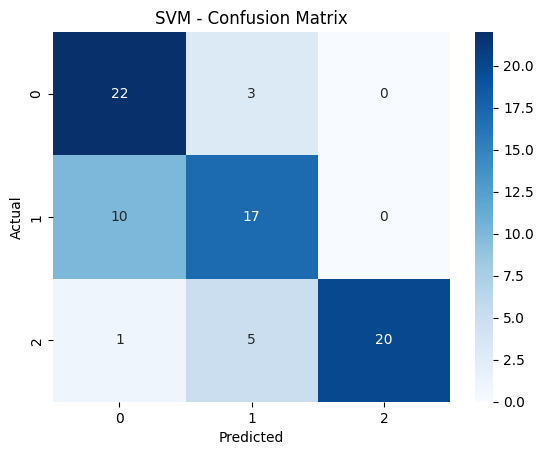

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    }

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [11]:
# Model Comparison Summary
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
results_df = pd.DataFrame(results).T
print(results_df.to_string())

best_model = results_df['F1-Score'].idxmax()
print(f"\nBest Model (by F1-Score): {best_model}")
print(f"F1-Score: {results_df.loc[best_model, 'F1-Score']}")


MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7436     0.7600  0.7436    0.7413
Decision Tree          0.5897     0.5806  0.5897    0.5799
Random Forest          0.7051     0.7341  0.7051    0.7127
SVM                    0.7564     0.7824  0.7564    0.7593

Best Model (by F1-Score): SVM
F1-Score: 0.7593


In [10]:
y_pred = model.predict(X_test)

print(pd.Series(y_pred).value_counts())

Good        33
Moderate    25
Poor        20
Name: count, dtype: int64


In [11]:
print("Actual:")
print(pd.Series(y_test).value_counts())

print("\nPredicted:")
print(pd.Series(y_pred).value_counts())

Actual:
sleep_quality
Moderate    27
Poor        26
Good        25
Name: count, dtype: int64

Predicted:
Good        33
Moderate    25
Poor        20
Name: count, dtype: int64


<Axes: >

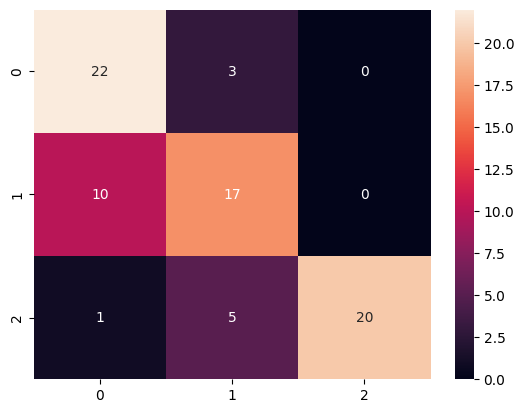

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Good       0.67      0.88      0.76        25
    Moderate       0.68      0.63      0.65        27
        Poor       1.00      0.77      0.87        26

    accuracy                           0.76        78
   macro avg       0.78      0.76      0.76        78
weighted avg       0.78      0.76      0.76        78



## Model Performance Analysis

Four supervised classification models were trained and evaluated on the Sleep Efficiency dataset: Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVM).

Among all models, SVM achieved the highest accuracy of 76%, and was selected as the best-performing model based on weighted F1-Score.

All three sleep quality classes — Good, Moderate, and Poor — were successfully predicted by the models. The Moderate Sleep class achieved a slightly lower F1-score of 0.65, which is expected as it represents an intermediate category whose feature values overlap with both Good and Poor Sleep.

The confusion matrices confirm that Moderate Sleep is occasionally misclassified as Good Sleep, reflecting the natural ambiguity between adjacent categories.

Overall, the models demonstrate balanced performance across all three classes and effectively capture the relationship between lifestyle factors and sleep quality.

In [12]:
import pickle

# Save the trained SVM model (best model)
best_model_obj = models["SVM"]

with open("sleepwise_model.pkl", "wb") as f:
    pickle.dump(best_model_obj, f)

# Save the scaler too (very important - we need it to transform new inputs)
with open("sleepwise_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save the label encoder
with open("sleepwise_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model, scaler and encoder saved successfully!")

Model, scaler and encoder saved successfully!


In [13]:
from google.colab import files
files.download("sleepwise_model.pkl")
files.download("sleepwise_scaler.pkl")
files.download("sleepwise_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Find rows predicted as Moderate
for i in range(len(X_test)):
    row = X_test[i].reshape(1, -1)
    pred = models["SVM"].predict(row)[0]
    if pred == "Moderate":
        print(f"Row {i}: {X_test[i]}")
        print(f"Original features: {X.iloc[i].to_dict()}")
        break

Row 4: [-0.76593641 -0.36945924 -1.07367489 -1.72451604 -1.71693184  0.65167663
  0.12013096  0.46357689 -0.49545358  1.70663452  1.08484962 -0.71981303
  1.47080431 -0.50950337]
Original features: {'ID': 5.0, 'Age': 57.0, 'Gender': 1.0, 'Bedtime': 66.0, 'Wakeup time': 66.0, 'Sleep duration': 8.0, 'REM sleep percentage': 27.0, 'Deep sleep percentage': 55.0, 'Light sleep percentage': 18.0, 'Awakenings': 3.0, 'Caffeine consumption': 0.0, 'Alcohol consumption': 3.0, 'Smoking status': 0.0, 'Exercise frequency': 3.0}
